# Hand Gesture Classification — Baseline
**Chris Marrero**



## 1. Imports & Device Setup

In [1]:
import os
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make sure to chnage the run time to use a T4 GPU in [Runtime > Change Runtime Type > T4 Gpu (Hardware accelerator)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: CUDA not available — training will be slow on CPU.')

Using device: cuda
GPU: Tesla T4
VRAM available: 15.6 GB


## 2. Download Dataset (Kaggle API)

This cell downloads the LeapGestRecog dataset from Kaggle using the official API.  
**Prerequisites:** place your `kaggle.json` API token in the same folder as this notebook.  
Get yours at https://www.kaggle.com/settings → API → Create New Token.

The cell automatically finds `kaggle.json` in the notebook directories content folder

In [ ]:
import os

notebook_dir = os.getcwd()
os.environ['KAGGLE_CONFIG_DIR'] = notebook_dir
print(f'Looking for kaggle.json in: {notebook_dir}')

kaggle_json_path = os.path.join(notebook_dir, 'kaggle.json')
if not os.path.exists(kaggle_json_path):
    raise FileNotFoundError(
        f'kaggle.json not found at {kaggle_json_path}\n'
        'Place your kaggle.json file in the same folder as this notebook.'
    )
print('kaggle.json found.')

import kaggle

DATASET_ROOT = Path('./leapgestrecog')

if not DATASET_ROOT.exists():
    print('Downloading LeapGestRecog dataset from Kaggle...')
    kaggle.api.dataset_download_files(
        'gti-upm/leapgestrecog',
        path=str(DATASET_ROOT),
        unzip=True
    )
    print('Download complete.')
else:
    print('Dataset folder already exists — skipping download.')

DATA_DIR = DATASET_ROOT / 'leapGestRecog'
print(f'Data directory: {DATA_DIR}')
print(f'Exists: {DATA_DIR.exists()}')

Looking for kaggle.json in: /content
kaggle.json found.
Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
Download complete.
Data directory: leapgestrecog/leapGestRecog
Exists: True


## 3. Dataset Loading


In [ ]:
image_paths = []
raw_labels  = []

for subject_dir in sorted(DATA_DIR.iterdir()):
    if not subject_dir.is_dir():
        continue

    for gesture_dir in sorted(subject_dir.iterdir()):
        if not gesture_dir.is_dir():
            continue

        gesture_name = gesture_dir.name
        label = '_'.join(gesture_name.split('_')[1:])

        for img_file in gesture_dir.glob('*.png'):
            image_paths.append(str(img_file))
            raw_labels.append(label)

print(f'Total images found: {len(image_paths)}')


le = LabelEncoder()
labels = le.fit_transform(raw_labels)

CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

print('\nImages per class:')
for name, count in sorted(Counter(raw_labels).items()):
    print(f'  {name:<15} {count}')

Total images found: 20000
Number of classes: 10
Classes: [np.str_('c'), np.str_('down'), np.str_('fist'), np.str_('fist_moved'), np.str_('index'), np.str_('l'), np.str_('ok'), np.str_('palm'), np.str_('palm_moved'), np.str_('thumb')]

Images per class:
  c               2000
  down            2000
  fist            2000
  fist_moved      2000
  index           2000
  l               2000
  ok              2000
  palm            2000
  palm_moved      2000
  thumb           2000


## 4. Preprocessing & Train/Val/Test Split



In [ ]:

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

image_paths = np.array(image_paths)
labels      = np.array(labels)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    random_state=SEED,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1111,
    random_state=SEED,
    stratify=y_trainval
)

print(f'Train size:      {len(X_train):>6}  ({len(X_train)/len(image_paths)*100:.1f}%)')
print(f'Validation size: {len(X_val):>6}  ({len(X_val)/len(image_paths)*100:.1f}%)')
print(f'Test size:       {len(X_test):>6}  ({len(X_test)/len(image_paths)*100:.1f}%)')

Train size:       16000  (80.0%)
Validation size:   2000  (10.0%)
Test size:         2000  (10.0%)


## 5. PyTorch Dataset & DataLoader


In [ ]:
class GestureDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


train_dataset = GestureDataset(X_train, y_train, transform=transform)
val_dataset   = GestureDataset(X_val,   y_val,   transform=transform)
test_dataset  = GestureDataset(X_test,  y_test,  transform=transform)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(device.type == 'cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == 'cuda')
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == 'cuda')
)

sample_imgs, sample_labels = next(iter(train_loader))
print(f'Batch image tensor shape: {sample_imgs.shape}')
print(f'Batch label tensor shape: {sample_labels.shape}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch image tensor shape: torch.Size([64, 1, 128, 128])
Batch label tensor shape: torch.Size([64])


## 6. CNN Model Definition

In [ ]:
class GestureCNN(nn.Module):
    """
    Custom CNN for 10-class hand gesture recognition.
    Built entirely from scratch — no pretrained weights.
    """

    def __init__(self, num_classes=10):
        super(GestureCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 128 → 64
        )


        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64 → 32
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32 → 16
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = GestureCNN(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

Model architecture:
GestureCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=

## 7. Training Loop

We train for 15 epochs. Each epoch consists of:
1. **Training phase**: feed batches through the model, compute loss, backpropagate gradients, update weights
2. **Validation phase**: evaluate on unseen data to check for overfitting (no gradient updates)


In [ ]:

criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 15

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
}

best_val_loss = float('inf')
best_model_path = 'best_model.pth'

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print('-' * 75)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>9} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()


    model.train()
    train_loss = 0.0
    train_correct = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, lbls)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == lbls).sum().item()


    train_loss /= len(train_dataset)
    train_acc   = train_correct / len(train_dataset)


    model.eval()
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == lbls).sum().item()

    val_loss /= len(val_dataset)
    val_acc   = val_correct / len(val_dataset)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_marker = ' ✓'
    else:
        saved_marker = ''

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - epoch_start
    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>9.4f} | {val_acc:>7.2%} | {elapsed:>5.1f}s{saved_marker}')

print('-' * 75)
print(f'Training complete. Best model saved to {best_model_path!r} (val loss: {best_val_loss:.4f})')

Training for 15 epochs on cuda...
---------------------------------------------------------------------------
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |   Time
---------------------------------------------------------------------------
     1 |     0.9296 |   78.04% |    0.0178 |  99.60% |  35.9s ✓
     2 |     0.0843 |   97.14% |    0.0083 |  99.85% |  35.1s ✓
     3 |     0.0555 |   98.22% |    0.0040 |  99.90% |  34.0s ✓
     4 |     0.0434 |   98.46% |    0.0132 |  99.75% |  35.0s
     5 |     0.0544 |   98.06% |    0.0025 |  99.90% |  34.2s ✓
     6 |     0.0409 |   98.61% |    0.0031 |  99.85% |  34.5s
     7 |     0.0311 |   98.87% |    0.0003 | 100.00% |  34.5s ✓
     8 |     0.0277 |   99.14% |    0.0015 |  99.95% |  33.5s
     9 |     0.0204 |   99.27% |    0.0007 |  99.95% |  34.9s
    10 |     0.0295 |   99.15% |    0.0003 | 100.00% |  34.9s ✓
    11 |     0.0235 |   99.21% |    0.0039 |  99.95% |  33.7s
    12 |     0.0212 |   99.28% |    0.0035 |  99.95% |  

## 8. Training Curves

Plotting loss and accuracy over epochs tells us:
- Whether training is converging (loss should decrease)
- Whether the model is overfitting (train acc >> val acc)

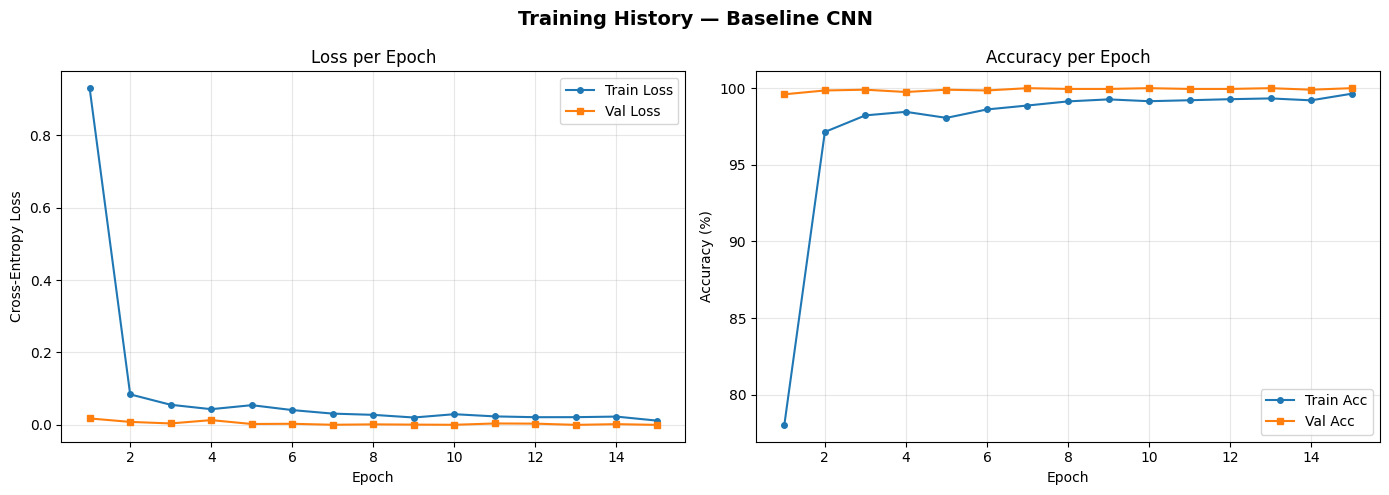

Saved: training_curves.png


In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Baseline CNN', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='s', markersize=4)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train Acc', marker='o', markersize=4)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val Acc',   marker='s', markersize=4)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## 9. Test Set Evaluation


Loaded best model from 'best_model.pth'

Test Accuracy: 0.9990 (99.90%)

Per-class classification report:
              precision    recall  f1-score   support

           c       1.00      1.00      1.00       200
        down       1.00      1.00      1.00       200
        fist       0.99      1.00      1.00       200
  fist_moved       1.00      1.00      1.00       200
       index       1.00      1.00      1.00       200
           l       1.00      1.00      1.00       200
          ok       1.00      1.00      1.00       200
        palm       1.00      1.00      1.00       200
  palm_moved       1.00      1.00      1.00       200
       thumb       1.00      0.99      0.99       200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



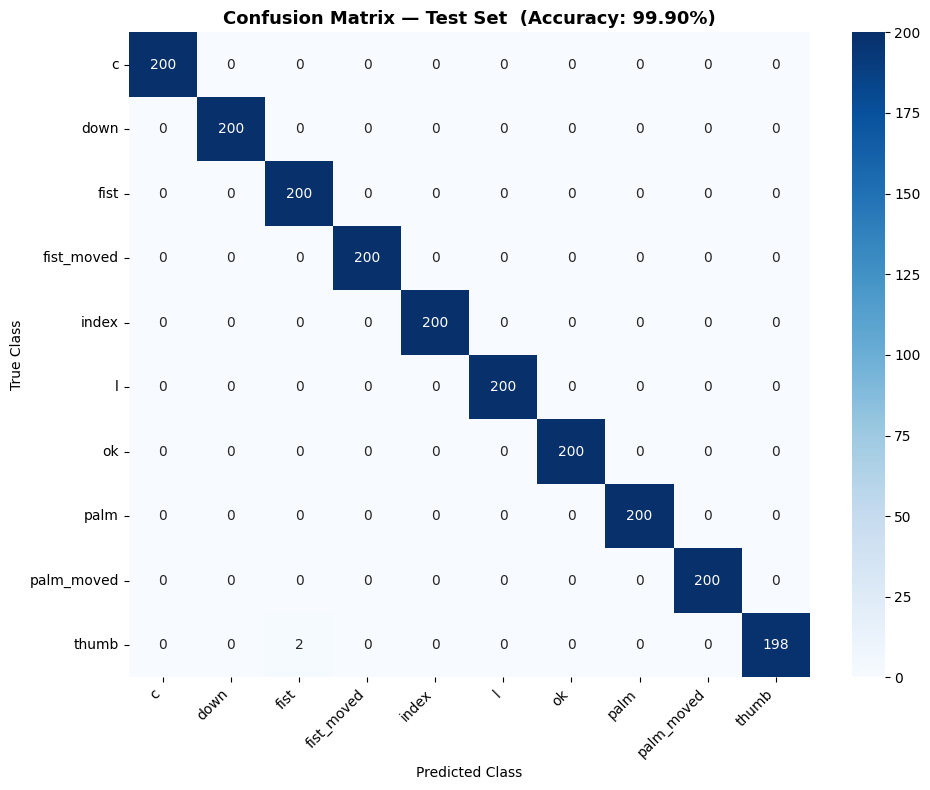

Saved: confusion_matrix.png


In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print(f'Loaded best model from {best_model_path!r}')

all_preds  = []
all_truths = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_truths.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_truths = np.array(all_truths)

test_acc = (all_preds == all_truths).mean()
print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

print('\nPer-class classification report:')
print(classification_report(all_truths, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_truths, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_title(f'Confusion Matrix — Test Set  (Accuracy: {test_acc*100:.2f}%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 10. Summary

In [ ]:
final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]

print('=' * 55)
print('  BASELINE CNN — RESULTS SUMMARY')
print('=' * 55)
print(f'  Architecture   : GestureCNN (3 conv blocks + 2 FC)')
print(f'  Total params   : {total_params:,}')
print(f'  Input size     : 128 × 128 px (grayscale)')
print(f'  Classes        : {NUM_CLASSES} ({", ".join(CLASS_NAMES)})')
print(f'  Epochs trained : {NUM_EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Optimizer      : Adam (lr=1e-3)')
print(f'  Loss           : CrossEntropyLoss')
print('-' * 55)
print(f'  Train Accuracy : {final_train_acc*100:.2f}%')
print(f'  Val Accuracy   : {final_val_acc*100:.2f}%')
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print('=' * 55)
print('  Artifacts saved:')
print('    best_model.pth       — model weights')
print('    training_curves.png  — loss & accuracy plots')
print('    confusion_matrix.png — per-class confusion')
print('=' * 55)

  BASELINE CNN — RESULTS SUMMARY
  Architecture   : GestureCNN (3 conv blocks + 2 FC)
  Total params   : 16,875,978
  Input size     : 128 × 128 px (grayscale)
  Classes        : 10 (c, down, fist, fist_moved, index, l, ok, palm, palm_moved, thumb)
  Epochs trained : 15
  Batch size     : 64
  Optimizer      : Adam (lr=1e-3)
  Loss           : CrossEntropyLoss
-------------------------------------------------------
  Train Accuracy : 99.64%
  Val Accuracy   : 100.00%
  Test Accuracy  : 99.90%
  Artifacts saved:
    best_model.pth       — model weights
    training_curves.png  — loss & accuracy plots
    confusion_matrix.png — per-class confusion
